# Customer Data Analysis for Business Insights

In [3]:
import pandas as pd

In [203]:
import seaborn as sns

In [204]:
import matplotlib.pyplot as plt

In [211]:
x=pd.read_csv('Customer_Master_Data.csv',parse_dates=['JoinDate'])

In [212]:
x.head()

,CustomerID,Name,Email,Gender,Age,City,MaritalStatus,NumChildren,JoinDate
0,CUST10000,Onkar Bhargava,pkeer@yahoo.com,Male,54,Delhi,Divorced,0,2021-02-22
1,CUST10001,Divit Kohli,mkalita@sarin.com,Female,48,Kolkata,Married,0,2023-12-06
2,CUST10002,Kiara Behl,apteanay@hotmail.com,Male,75,Kolkata,Widowed,2,2023-08-23
3,CUST10003,Vaibhav Sankar,bseshadri@choudhry.info,Male,62,Pune,Divorced,2,2022-11-17
4,CUST10004,Shray D’Alia,bdhillon@toor-mall.com,Male,55,Delhi,Divorced,0,2022-12-04


In [12]:
x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   CustomerID     1000 non-null   object        
 1   Name           1000 non-null   object        
 2   Email          1000 non-null   object        
 3   Gender         1000 non-null   object        
 4   Age            1000 non-null   int64         
 5   City           1000 non-null   object        
 6   MaritalStatus  1000 non-null   object        
 7   NumChildren    1000 non-null   int64         
 8   JoinDate       1000 non-null   datetime64[ns]
dtypes: datetime64[ns](1), int64(2), object(6)
memory usage: 70.4+ KB


In [16]:
y=pd.read_csv('Customer_Transactions.csv',parse_dates=['TransactionDate'])

/var/folders/6t/mrvjk_7110d2r0wjst3rcpkh0000gn/T/ipykernel_68789/3542527988.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  y=pd.read_csv('Customer_Transactions.csv',parse_dates=['TransactionDate'])


In [17]:
y.head()

,CustomerID,TransactionDate,TransactionAmount
0,CUST10771,2023-07-31,2383.07
1,CUST10100,2024-03-10,497.54
2,CUST10031,2025-02-17,536.78
3,CUST10987,2023-07-17,314.89
4,CUST10831,2024-12-15,2543.19


In [22]:
y.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23050 entries, 0 to 23049
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   CustomerID         23050 non-null  object        
 1   TransactionDate    23050 non-null  datetime64[ns]
 2   TransactionAmount  23050 non-null  float64       
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 540.4+ KB


In [20]:
x.shape

(1000, 9)

In [21]:
y.shape

(23050, 3)

## Checking NULL values for each columns

In [25]:
x.isnull().sum()/len(x.index)

CustomerID       0.0
Name             0.0
Email            0.0
Gender           0.0
Age              0.0
City             0.0
MaritalStatus    0.0
NumChildren      0.0
JoinDate         0.0
dtype: float64

In [26]:
y.isnull().sum()/len(x.index)

CustomerID           0.0
TransactionDate      0.0
TransactionAmount    0.0
dtype: float64

In [27]:
x.drop_duplicates(inplace=True)

In [28]:
y.drop_duplicates(inplace=True)

In [29]:
x

,CustomerID,Name,Email,Gender,Age,City,MaritalStatus,NumChildren,JoinDate
0,CUST10000,Onkar Bhargava,pkeer@yahoo.com,Male,54,Delhi,Divorced,0,2021-02-22
1,CUST10001,Divit Kohli,mkalita@sarin.com,Female,48,Kolkata,Married,0,2023-12-06
2,CUST10002,Kiara Behl,apteanay@hotmail.com,Male,75,Kolkata,Widowed,2,2023-08-23
3,CUST10003,Vaibhav Sankar,bseshadri@choudhry.info,Male,62,Pune,Divorced,2,2022-11-17
4,CUST10004,Shray D’Alia,bdhillon@toor-mall.com,Male,55,Delhi,Divorced,0,2022-12-04
...,...,...,...,...,...,...,...,...,...
995,CUST10995,Mehul Chada,hridaanagate@hotmail.com,Male,70,Hyderabad,Divorced,2,2020-07-29
996,CUST10996,Arhaan Tara,qwali@mand-sood.com,Male,35,Delhi,Single,1,2022-07-24
997,CUST10997,Mahika Uppal,vdalal@yahoo.com,Female,70,Ahmedabad,Married,3,2023-01-27
998,CUST10998,Bhamini Aggarwal,kartik15@bajaj-singhal.com,Male,37,Jaipur,Single,0,2022-07-22


In [30]:
y

,CustomerID,TransactionDate,TransactionAmount
0,CUST10771,2023-07-31,2383.07
1,CUST10100,2024-03-10,497.54
2,CUST10031,2025-02-17,536.78
3,CUST10987,2023-07-17,314.89
4,CUST10831,2024-12-15,2543.19
...,...,...,...
23045,CUST10710,2024-03-11,931.09
23046,CUST10209,2024-06-19,2659.35
23047,CUST10570,2024-06-27,266.97
23048,CUST10075,2023-12-26,1671.73


# Merging both files

In [33]:
df=pd.merge(x,y)
df

,CustomerID,Name,Email,Gender,Age,City,MaritalStatus,NumChildren,JoinDate,TransactionDate,TransactionAmount
0,CUST10000,Onkar Bhargava,pkeer@yahoo.com,Male,54,Delhi,Divorced,0,2021-02-22,2022-10-03,961.52
1,CUST10000,Onkar Bhargava,pkeer@yahoo.com,Male,54,Delhi,Divorced,0,2021-02-22,2024-05-31,92.16
2,CUST10000,Onkar Bhargava,pkeer@yahoo.com,Male,54,Delhi,Divorced,0,2021-02-22,2024-05-31,1153.74
3,CUST10000,Onkar Bhargava,pkeer@yahoo.com,Male,54,Delhi,Divorced,0,2021-02-22,2023-01-31,1217.04
4,CUST10000,Onkar Bhargava,pkeer@yahoo.com,Male,54,Delhi,Divorced,0,2021-02-22,2022-06-12,912.08
...,...,...,...,...,...,...,...,...,...,...,...
23045,CUST10999,Alia Sekhon,urvichadha@hotmail.com,Male,67,Hyderabad,Widowed,1,2021-09-07,2025-06-25,1883.60
23046,CUST10999,Alia Sekhon,urvichadha@hotmail.com,Male,67,Hyderabad,Widowed,1,2021-09-07,2025-02-12,243.54
23047,CUST10999,Alia Sekhon,urvichadha@hotmail.com,Male,67,Hyderabad,Widowed,1,2021-09-07,2024-10-09,1081.81
23048,CUST10999,Alia Sekhon,urvichadha@hotmail.com,Male,67,Hyderabad,Widowed,1,2021-09-07,2023-03-15,1619.39


In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23050 entries, 0 to 23049
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   CustomerID         23050 non-null  object        
 1   Name               23050 non-null  object        
 2   Email              23050 non-null  object        
 3   Gender             23050 non-null  object        
 4   Age                23050 non-null  int64         
 5   City               23050 non-null  object        
 6   MaritalStatus      23050 non-null  object        
 7   NumChildren        23050 non-null  int64         
 8   JoinDate           23050 non-null  datetime64[ns]
 9   TransactionDate    23050 non-null  datetime64[ns]
 10  TransactionAmount  23050 non-null  float64       
dtypes: datetime64[ns](2), float64(1), int64(2), object(6)
memory usage: 1.9+ MB


In [35]:
df.groupby('CustomerID')['TransactionAmount'].count()

CustomerID
CUST10000    23
CUST10001    30
CUST10002    24
CUST10003    25
CUST10004    19
             ..
CUST10995    21
CUST10996    21
CUST10997    20
CUST10998    25
CUST10999    23
Name: TransactionAmount, Length: 1000, dtype: int64

In [36]:
df.groupby('CustomerID')['TransactionAmount'].sum()

CustomerID
CUST10000    21265.49
CUST10001    28654.31
CUST10002    23884.03
CUST10003    24206.03
CUST10004    25565.30
               ...   
CUST10995    24325.19
CUST10996    21809.11
CUST10997    21120.48
CUST10998    29494.56
CUST10999    22028.01
Name: TransactionAmount, Length: 1000, dtype: float64

# Finding max_date

In [43]:
max_date = df['TransactionDate'].max() + pd.Timedelta(days=1) #pd.Timedelta(days=1) is used to add one extra day
max_date

Timestamp('2025-07-30 00:00:00')

# Find Regency, Frequency and Monetary

In [175]:
rfm = df.groupby('CustomerID').agg(
    Frequency=('CustomerID','count'),
    Monetary=('TransactionAmount','sum')
)

In [176]:
rfm['Recency'] = (max_date - df.groupby('CustomerID')['TransactionDate'].max()).dt.days

In [177]:
rfm

,Frequency,Monetary,Recency
CustomerID,,,
CUST10000,23,21265.49,13
CUST10001,30,28654.31,35
CUST10002,24,23884.03,18
CUST10003,25,24206.03,81
CUST10004,19,25565.30,8
...,...,...,...
CUST10995,21,24325.19,402
CUST10996,21,21809.11,15
CUST10997,20,21120.48,32


In [178]:
rfm['Frequency'].describe()

count    1000.000000
mean       23.050000
std         4.810472
min         6.000000
25%        20.000000
50%        23.000000
75%        26.000000
max        38.000000
Name: Frequency, dtype: float64

# Rank RFM values from 1-5

In [179]:
rfm['F_rank']=pd.qcut(rfm['Frequency'],q=5, labels=[1, 2, 3, 4,5])

In [180]:
rfm['M_rank']=pd.qcut(rfm['Monetary'],q=5, labels=[1, 2, 3, 4,5])

In [181]:
rfm['R_rank']=pd.qcut(rfm['Recency'],q=5, labels=[5,4,3,2,1])

In [182]:
rfm['RFM']=rfm['F_rank'].astype(str) + rfm['M_rank'].astype(str) + rfm['R_rank'].astype(str)

In [183]:
rfm

,Frequency,Monetary,Recency,F_rank,M_rank,R_rank,RFM
CustomerID,,,,,,,
CUST10000,23,21265.49,13,3,2,4,324
CUST10001,30,28654.31,35,5,5,3,553
CUST10002,24,23884.03,18,3,3,4,334
CUST10003,25,24206.03,81,4,3,1,431
CUST10004,19,25565.30,8,1,4,5,145
...,...,...,...,...,...,...,...
CUST10995,21,24325.19,402,2,3,1,231
CUST10996,21,21809.11,15,2,3,4,234
CUST10997,20,21120.48,32,2,2,3,223


# Assign values to Segment column based on specific condition

In [185]:
rfm['Segment']='Regular'

In [187]:
rfm.loc[
    ((rfm['R_rank'] >=4) &
     (rfm['F_rank'] >=4) &
     (rfm['M_rank'] >=4) &
     (rfm['Segment']=='Regular')),'Segment'] = 'Champions'

In [189]:
rfm.loc[((rfm['F_rank'] >=4) & (rfm['R_rank']>=2) & (rfm['Segment']=='Regular')),'Segment'] = 'Loyal Customers'

In [190]:
rfm.loc[((rfm['R_rank'] >=4) &
         ((rfm['F_rank'] >=2) & (rfm['F_rank'] <=3)) &
         (rfm['Segment']=='Regular')),'Segment'] = 'Potential Loyalist'

In [191]:
rfm.loc[(((rfm['R_rank'] >=1) & (rfm['R_rank'] <=2)) &
         ((rfm['F_rank'] >=3) & (rfm['F_rank'] <=5)) &
         (rfm['Segment']=='Regular')),'Segment'] = 'At Risk'

In [197]:
rfm.loc[((rfm['R_rank'] ==1) &
         ((rfm['F_rank'] >=1) & (rfm['F_rank'] <=2)) &
         ((rfm['M_rank'] >=1) & (rfm['M_rank'] <=2)) &
         (rfm['Segment']=='Regular')),'Segment'] = 'Lost'

In [198]:
rfm.loc[
    ((rfm['R_rank'] >= 3) & (rfm['R_rank'] <= 4)) &
    ((rfm['F_rank'] >= 2) & (rfm['F_rank'] <= 3)) &
    ((rfm['M_rank'] >= 4) & (rfm['M_rank'] <= 5)) &
    (rfm['Segment'] == 'Regular'),
    'Segment'
] = 'Big Spenders'

In [199]:
rfm.nunique()

Frequency      29
Monetary     1000
Recency       184
F_rank          5
M_rank          5
R_rank          5
RFM           104
Segment         5
dtype: int64

In [200]:
rfm

,Frequency,Monetary,Recency,F_rank,M_rank,R_rank,RFM,Segment
CustomerID,,,,,,,,
CUST10000,23,21265.49,13,3,2,4,324,Potential Loyalist
CUST10001,30,28654.31,35,5,5,3,553,Champions
CUST10002,24,23884.03,18,3,3,4,334,Potential Loyalist
CUST10003,25,24206.03,81,4,3,1,431,Loyal Customers
CUST10004,19,25565.30,8,1,4,5,145,Regular
...,...,...,...,...,...,...,...,...
CUST10995,21,24325.19,402,2,3,1,231,Potential Loyalist
CUST10996,21,21809.11,15,2,3,4,234,Potential Loyalist
CUST10997,20,21120.48,32,2,2,3,223,Potential Loyalist


# Ploting count graph

<Axes: xlabel='Segment', ylabel='count'>

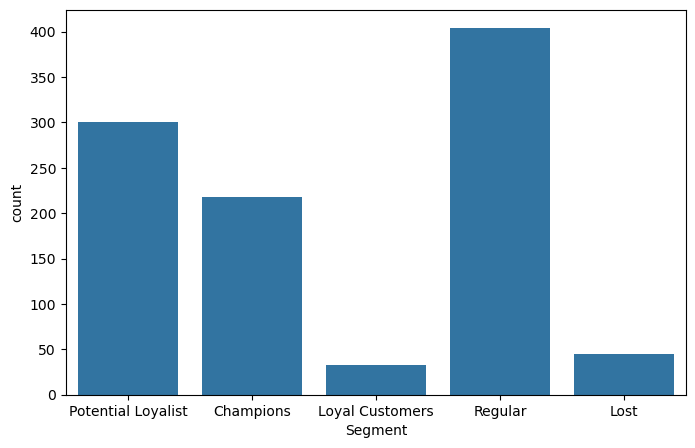

In [206]:
plt.figure(figsize=(8,5))
sns.countplot(data=rfm,x='Segment')

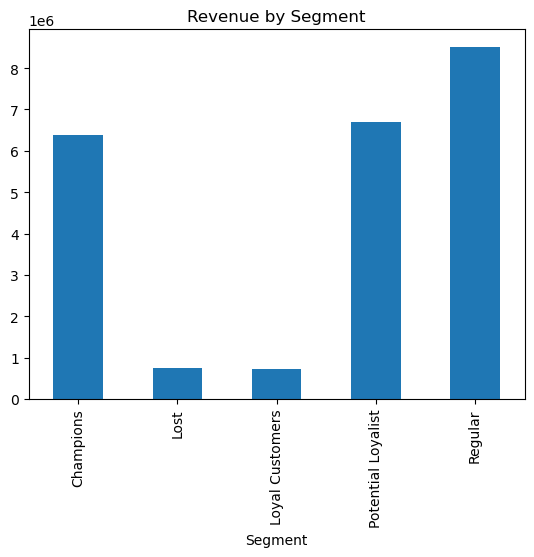

In [208]:
rfm.groupby('Segment')['Monetary'].sum().plot(kind='bar')
plt.title("Revenue by Segment")
plt.show()